In [1]:
import pandas as pd

df = pd.read_csv('D:\Downloads\FIFA2023.csv')
df.head()

,Full Name,Value(in Euro),Overall,Reactions,Dribbling Total,Passing Total,Positions Played,Best Position,Nationality,Club Name
0,Lionel Messi,54000000,91,92,94,90,RW,CAM,Argentina,Paris Saint-Germain
1,Karim Benzema,64000000,91,92,87,83,"CF,ST",CF,France,Real Madrid CF
2,Robert Lewandowski,84000000,91,93,86,79,ST,ST,Poland,FC Barcelona
3,Kevin De Bruyne,107500000,91,91,87,93,"CM,CAM",CM,Belgium,Manchester City
4,Kylian Mbappé,190500000,91,93,92,80,"ST,LW",ST,France,Paris Saint-Germain


In [30]:
df['Position check'] = df.apply(lambda x: 
                                1 if x['Positions Played'] == x['Best Position']
                                else 0, axis = 1)
round(df['Position check'].mean(), 2)

0.42

In [32]:
df.corr(numeric_only = True)

,Value(in Euro),Overall,Reactions,Dribbling Total,Passing Total,Position check,ln_Value
Value(in Euro),1.000000,0.561642,0.498667,0.406424,0.399985,-0.026051,0.520346
Overall,0.561642,1.000000,0.872789,0.674971,0.699315,-0.053152,0.648548
Reactions,0.498667,0.872789,1.000000,0.589903,0.615912,-0.083064,0.557830
Dribbling Total,0.406424,0.674971,0.589903,1.000000,0.842927,-0.280647,0.472940
Passing Total,0.399985,0.699315,0.615912,0.842927,1.000000,-0.280297,0.445670
Position check,-0.026051,-0.053152,-0.083064,-0.280647,-0.280297,1.000000,-0.094868
ln_Value,0.520346,0.648548,0.557830,0.472940,0.445670,-0.094868,1.000000


In [33]:
from sklearn.model_selection import train_test_split

X = df[['Overall', 'Dribbling Total', 'Position check']]
y = df['Value(in Euro)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [34]:
from sklearn.linear_model import LinearRegression
model1 = LinearRegression().fit(X_train, y_train)

In [37]:
model1.coef_.round(2)

array([592521.16,  53767.17, 393580.53])

In [38]:
model1.intercept_.round(2)

-39664500.28

$$ \text{Value} = -39664500.28 + 592521.16*\text{Overall} + 53767.17 * \text{Dribbling Total} + 393580.53*\text{Position check}$$

In [ ]:
Value  = w0 + 59252116*ln(Overall)

$$MSE = \frac{\Sigma (y - \widehat{y})^2}{n} $$

$$MAE = \frac{\Sigma| y - \widehat{y}|}{n} $$

In [39]:
from sklearn.metrics import mean_squared_error, r2_score
y_test_pred = model1.predict(X_test) #ищем предсказанные значения
print('MSE', round(mean_squared_error(y_test, y_test_pred), 2))
print('MAE', round(sum(abs(y_test-y_test_pred))/len(y_test), 2))
print('R2', round(r2_score(y_test, y_test_pred), 2))

MSE 33629039030456.67
MAE 3157735.11
R2 0.32


<AxesSubplot:ylabel='Frequency'>

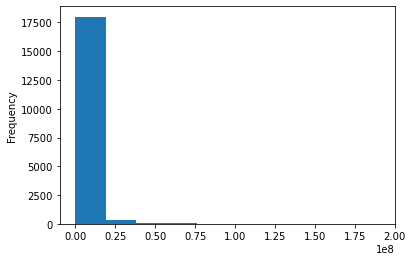

In [40]:
y.plot(kind = 'hist')

<AxesSubplot:ylabel='Frequency'>

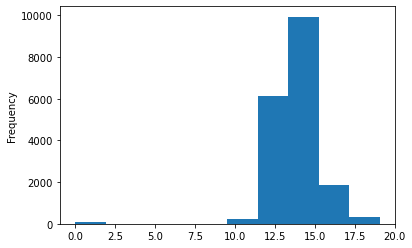

In [41]:
import numpy as np
df['ln_Value'] = np.log1p(y)
df['ln_Value'].plot(kind = 'hist')

In [42]:
q1 = df['ln_Value'].quantile(0.25)
q3 = df['ln_Value'].quantile(0.75)
iqr = q3 - q1
l = q1 - 1.5*iqr
r = q3 + 1.5*iqr

df_clean = df[(df['ln_Value']>l) & (df['ln_Value']<r)]
df_clean.shape[0]

17763

<AxesSubplot:ylabel='Frequency'>

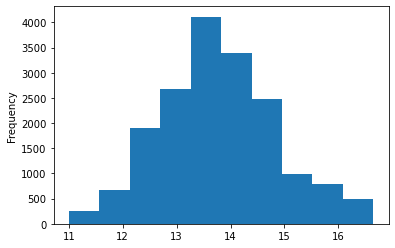

In [43]:
df_clean['ln_Value'].plot(kind = 'hist')

In [44]:
X = df_clean[['Overall', 'Dribbling Total', 'Position check']]
y = df_clean['ln_Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [45]:
model2 = LinearRegression().fit(X_train, y_train)

In [46]:
y_test_pred = model2.predict(X_test) #ищем предсказанные значения
print('MSE', round(mean_squared_error(y_test, y_test_pred), 2))
print('MAE', round(sum(abs(y_test-y_test_pred))/len(y_test), 2))
print('R2', round(r2_score(y_test, y_test_pred), 2))

MSE 0.27
MAE 0.4
R2 0.76


In [47]:
model2.coef_.round(2)

array([ 0.14,  0.01, -0.14])

In [48]:
model2.intercept_.round(2)

4.2

$$ ln(\text{Value}+1)  =  4.2 + 0.14*\text{Overall} + 0.01*\text{Dribbling Total} -0.14*\text{Position check} $$

In [ ]:
ln(Value+1) = 4.2


In [51]:
round(np.exp(model2.intercept_)-1,2) #Value+1

65.57

In [54]:
round(np.exp(4.2)-1, 2)

65.69